# Multi-class Prediction of Chronic Kidney Disease Stages

**Autori:** Marija Todorović IN 13/2022, Nenad Lukić IN 17/2022  
**Baza podataka:** [Kidney Disease Dataset – Kaggle](https://www.kaggle.com/datasets/amanik000/kidney-disease-dataset)

---

### Opis problema

Skup podataka sadrži medicinske i demografske podatke o pacijentima koji se koriste za procenu hronične bolesti bubrega. Problem je definisan kao višeklasna klasifikacija sa pet kategorija ciljne promenljive:

| Klasa | Opis | Udeo u skupu |
|---|---|---|
| No_Disease | Nema bolesti | ~80.0% |
| Low_Risk | Mali rizik | ~10.0% |
| Moderate_Risk | Srednji rizik | ~4.0% |
| High_Risk | Visoki rizik | ~4.0% |
| Severe_Disease | Ozbiljna bolest | ~2.0% |

**Napomena:** Skup podataka je izrazito neuravnotežen – dominantna klasa čini 80% uzoraka. Ovo će biti uzeto u obzir tokom modelovanja.

### Plan rada
1. Učitavanje i inicijalni pregled podataka
2. Eksplorativna analiza (EDA)
3. Priprema podataka (preprocessing)
4. Klasifikacija: kNN
5. Klasifikacija: Random Forest
6. Klasifikacija: SVM
7. Redukcija dimenzionalnosti (PCA, LDA) + ponovna klasifikacija
8. Poređenje rezultata i zaključak


---
# 1. Učitavanje biblioteka i podataka

In [63]:
# Standardne biblioteke
import numpy as np
import pandas as pd 

# Vizualizacija
import matplotlib.pyplot as plt
import seaborn as sb

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)

In [64]:
# Učitavanje skupa podataka
df = pd.read_csv('kidney_disease_dataset.csv')
print(f'Dimenzije skupa: {df.shape}')
print(f'Broj uzoraka: {df.shape[0]}, Broj obeležja: {df.shape[1]}')
df.head()

Dimenzije skupa: (20538, 43)
Broj uzoraka: 20538, Broj obeležja: 43


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


---
## 2. Eksplorativna analiza podataka (EDA)

Cilj ove sekcije je da steknemo uvid u strukturu podataka: tipove obeležja, raspodelu vrednosti, neuravnoteženost klasa i međusobne korelacije numeričkih obeležja.

In [65]:
# Deskriptivna statistika numeričkih obeležja
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age of the patient,20538.0,47.477895,24.941947,5.000000,26.000000,47.000000,69.000000,90.000000
Blood pressure (mm/Hg),20538.0,130.352079,29.063838,80.000000,105.000000,131.000000,156.000000,180.000000
Specific gravity of urine,20538.0,1.015041,0.005793,1.005000,1.010000,1.015000,1.020000,1.025000
Albumin in urine,20538.0,2.501266,1.697084,0.000000,1.000000,3.000000,4.000000,5.000000
Sugar in urine,20538.0,2.494595,1.701059,0.000000,1.000000,2.000000,4.000000,5.000000
Random blood glucose level (mg/dl),20538.0,284.630295,124.633265,70.000000,176.000000,284.500000,393.000000,500.000000
Blood urea (mg/dl),20538.0,104.094240,55.726482,7.002370,55.864665,104.401355,152.480048,199.994361
Serum creatinine (mg/dl),20538.0,7.781865,4.179925,0.500000,4.200000,7.780000,11.430000,15.000000
Sodium level (mEq/L),20538.0,135.076646,8.651000,120.000613,127.563468,135.044974,142.607311,149.999914
Potassium level (mEq/L),20538.0,4.992314,0.871026,3.500005,4.229885,4.990991,5.749899,6.499827


Broj uzoraka po klasi:
                 Broj  Procenat (%)
Target                             
No_Disease      16432         80.01
Low_Risk         2054         10.00
Moderate_Risk     821          4.00
High_Risk         821          4.00
Severe_Disease    410          2.00


C:\Users\necal\AppData\Local\Temp\ipykernel_14744\2789017744.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x=class_counts.index, y=class_counts.values, palette='Set2', ax=axes[0])


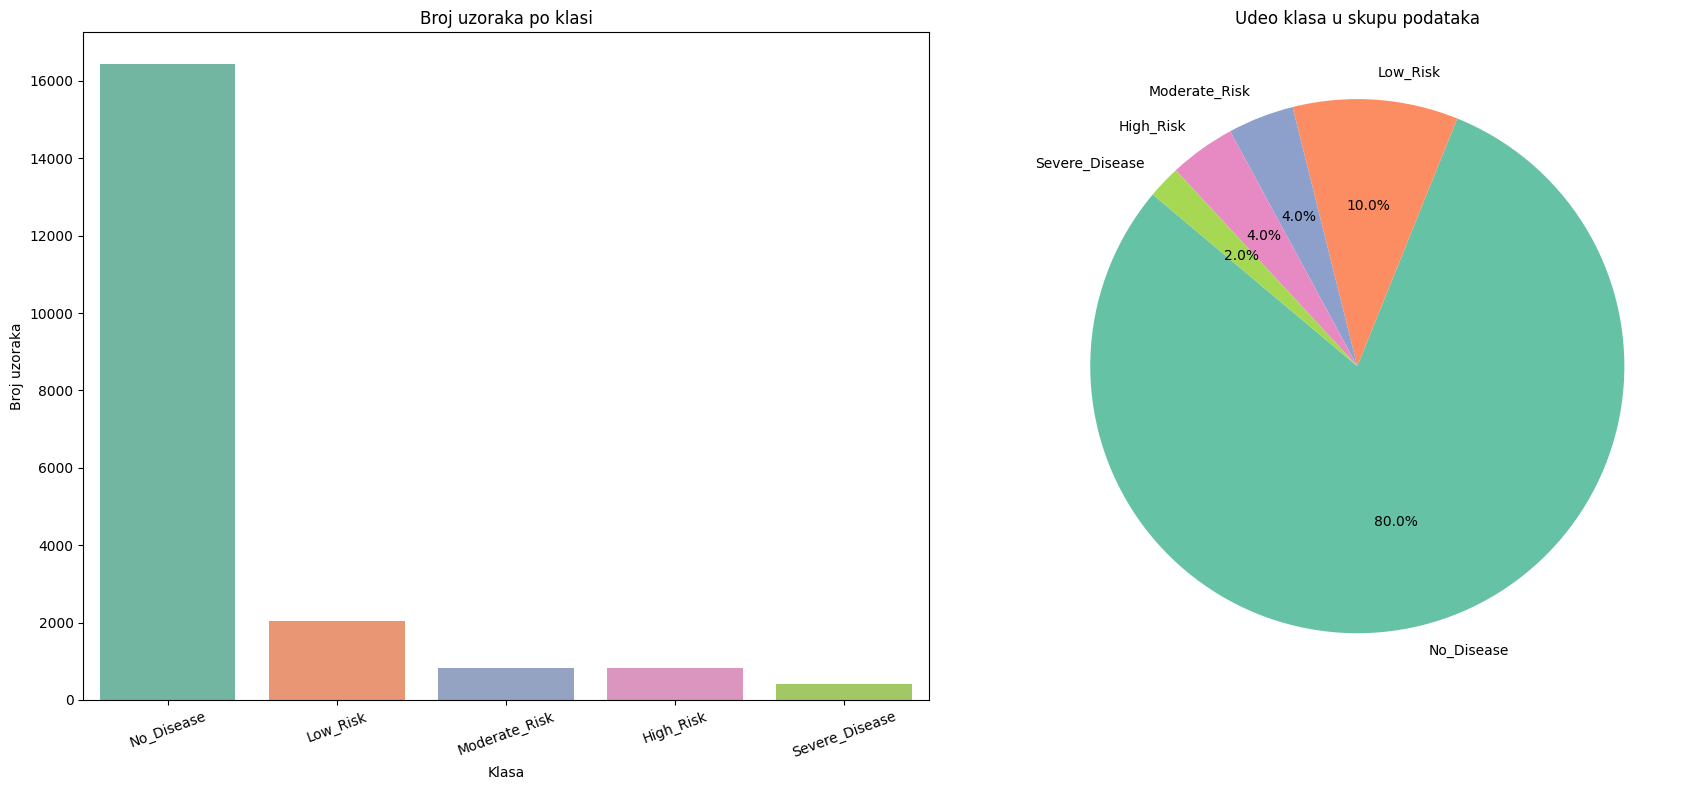

In [66]:
# Raspodela ciljne promenljive
target_col = 'Target'  

class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100

print('Broj uzoraka po klasi:')
print(pd.DataFrame({'Broj': class_counts, 'Procenat (%)': class_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Barplot
sb.barplot(x=class_counts.index, y=class_counts.values, palette='Set2', ax=axes[0])
axes[0].set_title('Broj uzoraka po klasi')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj uzoraka')
axes[0].tick_params(axis='x', rotation=20)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=sb.color_palette('Set2', len(class_counts)))
axes[1].set_title('Udeo klasa u skupu podataka')

plt.tight_layout()
plt.savefig('Prilozi/01_raspodela_klasa.png', dpi=150, bbox_inches='tight')
plt.show()

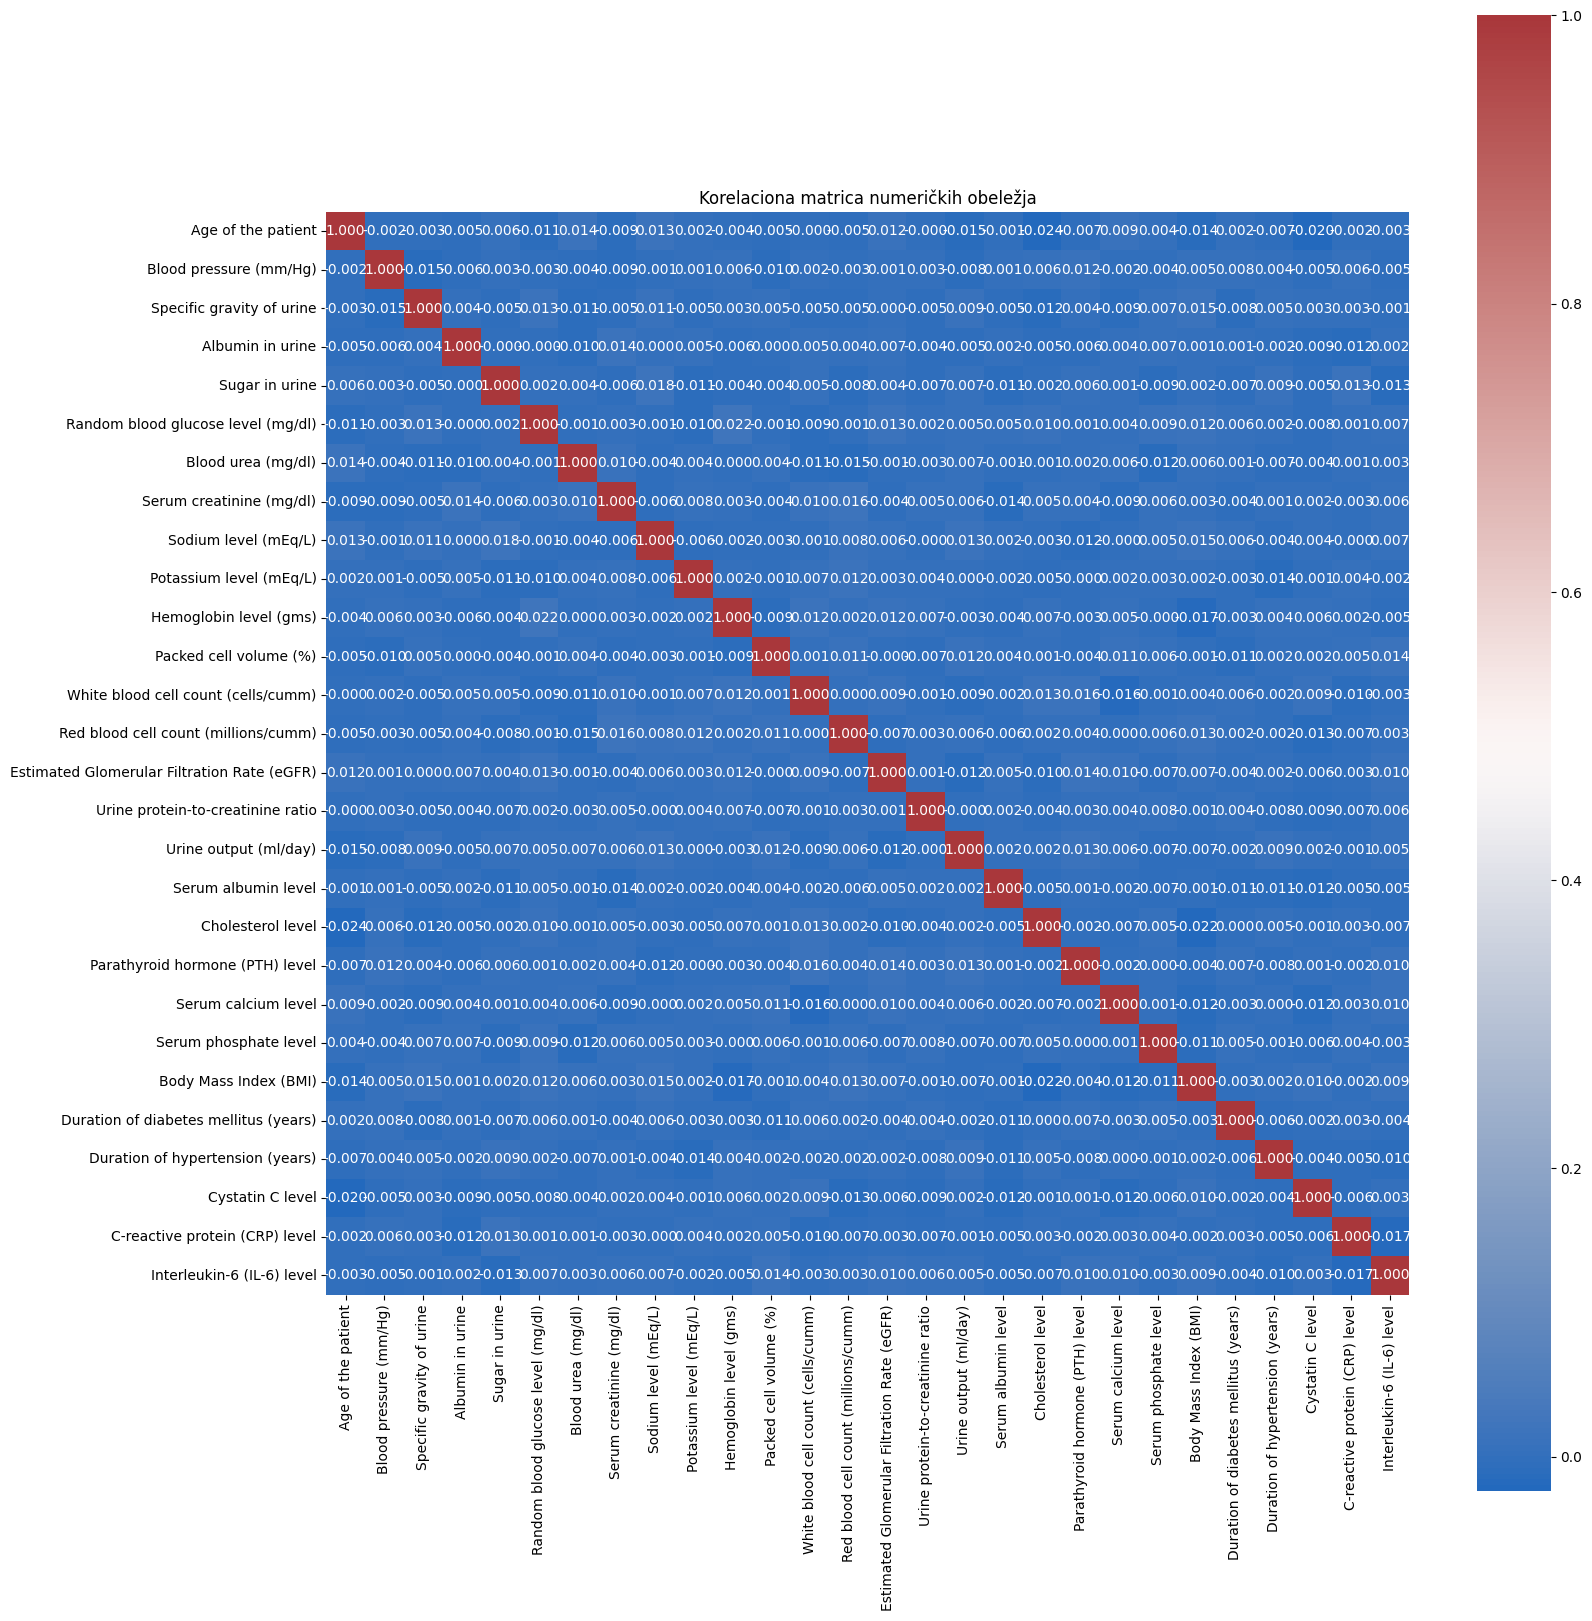

In [67]:
# Korelaciona matrica numeričkih obeležja 
numerical = df.select_dtypes(include=['int64', 'float64'])
corr = numerical.corr(method='pearson')

plt.figure(figsize=(17,17))
sb.heatmap(corr, annot=True, fmt=".3f", cmap="vlag", square=True)
plt.title("Korelaciona matrica numeričkih obeležja")
plt.tight_layout()
plt.savefig('Prilozi/02_korelaciona_matrica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Priprema podataka (Preprocessing)

U ovoj sekciji:
- Definišemo cilj i obeležja
- Izbacujemo obeležja koja su identifikovana kao neinformativna (specifična gravitacija urina, albumin u urinu)
- Delimo skup na train (85%) i test (15%) deo, stratifikovano zbog neuravnoteženosti klasa
- Vršimo transformacije obeležja: 
    - Skaliramo numerička obeležja i 
    - Enkodujemo kategorička obeležja.
- Kreiramo petostruku podelu podataka za unakrsnu validaciju

In [68]:
# Definišemo cilj i obeležja
target_col = 'Target'

cat_cols = ['Sugar in urine', 'Albumin in urine',
            'Red blood cells in urine', 'Pus cells in urine', 
            'Pus cell clumps in urine', 
            'Bacteria in urine', 'Hypertension (yes/no)', 
            'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)', 
            'Appetite (good/poor)', 'Pedal edema (yes/no)', 
            'Anemia (yes/no)', 'Family history of chronic kidney disease', 
            'Smoking status', 'Physical activity level', 
            'Urinary sediment microscopy results'
        ]

num_cols = list(set(df.columns) - set(cat_cols) - {target_col})

print("Numerička obeležja:", num_cols)
print('Broj numeričkih obeležja:', len(num_cols))

print()

print("Kategorička obeležja:", cat_cols)
print('Broj kategoričkih obeležja:', len(cat_cols))

print()

print("Ciljano obeležje:", target_col)


Numerička obeležja: ['Potassium level (mEq/L)', 'Hemoglobin level (gms)', 'Urine protein-to-creatinine ratio', 'Blood pressure (mm/Hg)', 'White blood cell count (cells/cumm)', 'Serum phosphate level', 'Parathyroid hormone (PTH) level', 'Interleukin-6 (IL-6) level', 'Red blood cell count (millions/cumm)', 'Packed cell volume (%)', 'Serum calcium level', 'Specific gravity of urine', 'C-reactive protein (CRP) level', 'Duration of hypertension (years)', 'Cholesterol level', 'Serum creatinine (mg/dl)', 'Cystatin C level', 'Duration of diabetes mellitus (years)', 'Age of the patient', 'Blood urea (mg/dl)', 'Random blood glucose level (mg/dl)', 'Body Mass Index (BMI)', 'Serum albumin level', 'Estimated Glomerular Filtration Rate (eGFR)', 'Sodium level (mEq/L)', 'Urine output (ml/day)']
Broj numeričkih obeležja: 26

Kategorička obeležja: ['Sugar in urine', 'Albumin in urine', 'Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine', 'Bacteria in urine', 'Hypertension (yes/n

In [69]:
# Izbacivanje neinformativnih kolona
cols_to_drop = ['Specific gravity of urine', 'Albumin in urine']

num_cols.remove('Specific gravity of urine')
cat_cols.remove('Albumin in urine')

cols_to_drop = [c for c in cols_to_drop if c in df.columns]   # Zelim da izbacim samo kolone koje postoje
df_clean = df.drop(columns=cols_to_drop)

print(f'Broj obeležja pre čišćenja: {df.shape[1]}')
print(f'Broj obeležja posle čišćenja: {df_clean.shape[1]}')
print(f'Izbačena obeležja: {cols_to_drop}')

Broj obeležja pre čišćenja: 43
Broj obeležja posle čišćenja: 41
Izbačena obeležja: ['Specific gravity of urine', 'Albumin in urine']


In [70]:
# Razdvajanje obeležja i ciljne promenljive
X = df_clean[num_cols + cat_cols].copy()
y = df_clean[target_col].copy()

print("Dimenzije X:", X.shape)
print("Dimenzije y:", y.shape)
print("Klase ciljnog obeležja:", y.unique())

# Train/Test podela (stratifikovana)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # Zbog neuravnoteženosti!
)

print(f'\nTrainval skup sadrži: {X_trainval.shape[0]} uzoraka')
print(f'Test skup sadrži: {X_test.shape[0]} uzoraka')
print(f'\nRaspodela klasa u trainval skupu:')
print(y_trainval.value_counts().sort_index())

Dimenzije X: (20538, 40)
Dimenzije y: (20538,)
Klase ciljnog obeležja: ['No_Disease' 'Low_Risk' 'Moderate_Risk' 'Severe_Disease' 'High_Risk']

Trainval skup sadrži: 17457 uzoraka
Test skup sadrži: 3081 uzoraka

Raspodela klasa u trainval skupu:
Target
High_Risk           698
Low_Risk           1746
Moderate_Risk       698
No_Disease        13967
Severe_Disease      348
Name: count, dtype: int64


Upotrebom ColumnTransformer-a će biti primenjene sledeće tehnike u odnosu na vrste kolona: 
- Nad kategoričkim kolonama će biti primenjena One Hot Encoding tehnika (OneHotEncoder() će biti primenjen) i
- Nad numeričkim obeležjima će biti urađeno skaliranje (StandardScaler() će biti primenjen). 

In [ ]:
# Koristiće se za transformaciju obeležja
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(), cat_cols),
    ],
    remainder="drop"
)

# Kreiranje podele za unakrsnu validaciju
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

---
## 4. kNN Klasifikator

Za ovo, a verovatno i za naredne klasifikatore, potrebno je primeniti GridSearchCV kako bismo pronašli optimalan set hiperparametara za datu vrstu klasifikatora.

Zatim za najbolji set hiperparametara ponovno pokrećemo trening nad trainval skupom i prikazujemo rezultat nad testnim skupom.

Konačno, prikazujemo i matricu konfuzije.

Napomena: Mislim da treba da koristimo F1_score i prilikom GridSearchCV zbog sledećeg što je navedeno u "Dodatne informacije/Plan rada.txt"

```
4. Mere uspešnosti:
- Planiramo da koristimo F1_score (macro prosek) kao meru uspešnosti uz prikaz matrice konfuzije i uz eventualno prikazivanje ostalih mera kao što su: precision, accuracy i recall.
```

Ako je verovati Claude, onda treba da koristimo F1_score i tokom pretrage hiperparametara i na kraju pri prikazu rezultata.

```python
from sklearn.metrics import make_scorer
scorer = make_scorer(f1_score, average='macro')
grid_search = GridSearchCV(
    ...
    scoring=scorer,        # F1 macro kao kriterijum
)
```

---
## 5. Klasifikator baziran na Random Forest metodi

---
## 6. SVM Klasifikator baziran na pristupu: jedan protiv svih